# Exercise

Vocabulary size: 30522
Number of classes: 3
First example from the dataset:
[CLS] conceptually cream skimming has two basic dimensions - product and geography. [SEP] product and geography are what make cream skimming work. [SEP]
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MLPClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─Linear: 1-2                            [32, 64]                  [32, 64]                  4,160
├─Linear: 1-3                            [32, 64]                  [32, 3]                   195
Total params: 1,957,763
Trainable params: 1,957,763
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 62.65
Input size (MB): 0.02
Forward/backward pass size (MB): 1.07
Params size (MB): 7.83
Estimated Total Size (MB): 8.91
Epoch 1: Train Acc = 0.346, Val Acc = 0.367

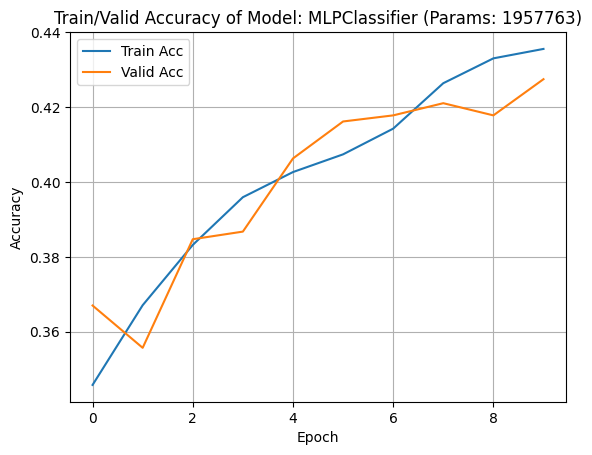

Test Accuracy: 0.435
              precision    recall  f1-score   support

           0       0.46      0.24      0.32      3463
           1       0.38      0.50      0.43      3129
           2       0.48      0.58      0.53      3240

    accuracy                           0.43      9832
   macro avg       0.44      0.44      0.42      9832
weighted avg       0.44      0.43      0.42      9832



In [ ]:
# (1) Data Loading
# Tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
vocab_size = tokenizer.vocab_size
print(f"Vocabulary size: {vocab_size}")

# Dataset
from torch.utils.data import RandomSampler
# IMDb Dataset
from datasets import load_dataset
dataset = load_dataset("imdb")
num_classes = len(dataset["train"].features["label"].names)
print(f"Number of classes: {num_classes}")
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=False)
tokenized = dataset.map(tokenize, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_trainval = tokenized["train"].train_test_split(test_size=0.2, seed=42)
train_set = tokenized_trainval["train"]
val_set = tokenized_trainval["test"]
test_set = tokenized["test"]
subset_size = len(train_set) // 2   # 1/2 of the training set is used
train_sampler = RandomSampler(train_set, num_samples=subset_size)

# MultiNLI Dataset
# from datasets import load_dataset
# dataset = load_dataset("multi_nli")
# num_classes = len(dataset["train"].features["label"].names)
# print(f"Number of classes: {num_classes}")
# def tokenize(batch):
#     return tokenizer(batch["premise"], batch["hypothesis"], truncation=True, padding=False)
# tokenized = dataset.map(tokenize, batched=True)
# tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
# train_set = tokenized["train"]
# val_set = tokenized["validation_matched"]
# test_set = tokenized["validation_mismatched"]
# subset_size = len(train_set) // 30   # 1/30 of the training set is used
# train_sampler = RandomSampler(train_set, num_samples=subset_size)

# Print the first example
print("First example from the dataset:")
print("Sentence:", tokenizer.decode(train_set[0]["input_ids"]))
print("Label:", dataset["train"].features["label"].names[train_set[0]["label"]])

# (2) DataLoader with padding
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

def collate_fn(batch):
    input_ids = pad_sequence([x["input_ids"] for x in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    attn_mask = pad_sequence([x["attention_mask"] for x in batch], batch_first=True, padding_value=0)
    labels = torch.tensor([x["label"] for x in batch])
    return input_ids, attn_mask, labels

train_loader = DataLoader(train_set, batch_size=32, sampler=train_sampler, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, collate_fn=collate_fn)

# (3) Model Definition
import torch.nn as nn

# MLP Classifier
class MLPClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)  # (B, L) -> (B, L, embed_dim)
        emb = emb.mean(dim=1)  # (B, L, embed_dim) -> (B, embed_dim)
        out = torch.relu(self.fc1(emb)) # (B, embed_dim) -> (B, hidden_dim)
        return self.fc2(out)  # (B, hidden_dim) -> (B, num_classes)

# RNN Classifier
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.rnn = nn.RNN(embed_dim, hidden_dim, bidirectional=False, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids) # (B, L) -> (B, L, embed_dim)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, hn = self.rnn(packed)  # (B, L, embed_dim) -> (1, B, hidden_dim)
        return self.fc(hn[0])  # (1, B, hidden_dim) -> (B, num_classes)

# Bi-RNN Classifier
class BiRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.rnn = nn.RNN(embed_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)  # (B, L) -> (B, L, embed_dim)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, hn = self.rnn(packed)  # (B, L, embed_dim) -> (2, B, hidden_dim)
        out = torch.cat((hn[0], hn[1]), dim=1)  # (2, B, hidden_dim) -> (B, hidden_dim * 2)
        return self.fc(out)  # (B, hidden_dim * 2) -> (B, num_classes)

# LSTM Classifier
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, bidirectional=False, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)  # (B, L) -> (B, L, embed_dim)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.lstm(packed)  # (B, L, embed_dim) -> (1, B, hidden_dim)
        return self.fc(hn[0])  # (1, B, hidden_dim) -> (B, num_classes)

# Bi-LSTM Classifier
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)  # (B, L) -> (B, L, embed_dim)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.lstm(packed)  # (B, L, embed_dim) -> (2, B, hidden_dim)
        out = torch.cat((hn[0], hn[1]), dim=1)  # (2, B, hidden_dim) -> (B, hidden_dim * 2)
        return self.fc(out)  # (B, hidden_dim * 2) -> (B, num_classes)


# (4) Training function
import torch.optim as optim

def train(train_loader, val_loader, model, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, mask, y in train_loader:
            x, mask, y = x.to(device), mask.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x, mask)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, mask, y in val_loader:
                x, mask, y = x.to(device), mask.to(device), y.to(device)
                out = model(x, mask)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state

# (5) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embed_dim = 64
hidden_dim = 64
model = MLPClassifier(vocab_size, embed_dim, hidden_dim, num_classes).to(device)

import torchinfo
print(torchinfo.summary(
    model,
    input_data=(torch.randint(0, vocab_size, (32, 64), device=device),
                torch.ones(32, 64, dtype=torch.int64, device=device)),
    col_names=["input_size", "output_size", "num_params"]
))

train_accs, test_accs, best_state = train(train_loader, val_loader, model, device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Valid Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Train/Valid Accuracy of Model: {model.__class__.__name__} (Params: {num_params})")
plt.legend()
plt.grid(True)
plt.show()

# (6) Evaluate on test set
model.load_state_dict(best_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, mask, y in test_loader:
        x, mask, y = x.to(device), mask.to(device), y.to(device)
        out = model(x, mask)
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(y.cpu())
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
print(f"Test Accuracy: {torch.sum(all_preds == all_labels).item() / len(all_labels):.3f}")

from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy()))

# Exercise: Comparison (IMDb)

Vocabulary size: 30522
Number of classes: 2
First example from the dataset:
[CLS] stage adaptations often have a major fault. they often come out looking like a film camera was simply placed on the stage ( such as " night mother " ). sidney lumet ' s direction keeps the film alive, which is especially difficult since the picture offered him no real challenge. still, it ' s nice to look at for what it is. the chemistry between michael caine and christopher reeve is quite brilliant. the dynamics of their relationship are surprising. caine is fantastic as always, and reeve gets one of his few chances to really act. < br / > < br / > i confess that i ' ve never seen ira levin ' s play, but i hear that jay presson allen ' s adaptation is faithful. the script is incredibly convoluted, and keeps you guessing. " deathtrap " is an enormously entertaining film, and is recommended for nearly all fans of stage and screen. < br / > < br / > 7. 4 out of 10 [SEP]
pos
Layer (type:depth-idx)           

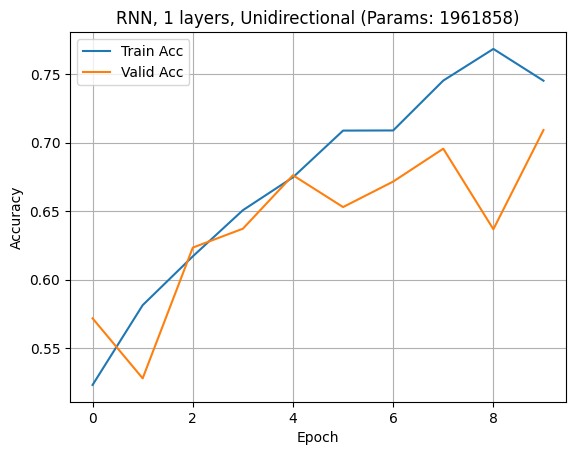

Test Accuracy: 0.719
              precision    recall  f1-score   support

           0       0.71      0.75      0.73     12500
           1       0.73      0.69      0.71     12500

    accuracy                           0.72     25000
   macro avg       0.72      0.72      0.72     25000
weighted avg       0.72      0.72      0.72     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─RNN: 1-2                               [2048, 64]                [2048, 64]                16,640
├─Linear: 1-3                            [32, 64]                  [32, 2]                   130
Total params: 1,970,178
Trainable params: 1,970,178
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 2.24
Input size (MB): 0.03
Forward/backward 

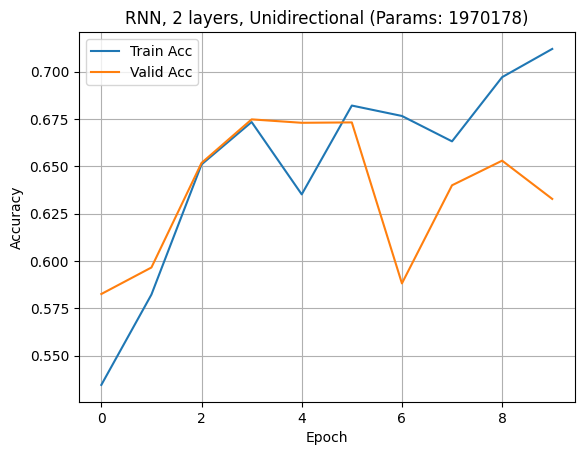

Test Accuracy: 0.639
              precision    recall  f1-score   support

           0       0.59      0.90      0.71     12500
           1       0.79      0.38      0.51     12500

    accuracy                           0.64     25000
   macro avg       0.69      0.64      0.61     25000
weighted avg       0.69      0.64      0.61     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─RNN: 1-2                               [2048, 64]                [2048, 128]               16,640
├─Linear: 1-3                            [32, 128]                 [32, 2]                   258
Total params: 1,970,306
Trainable params: 1,970,306
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 4.42
Input size (MB): 0.03
Forward/backward 

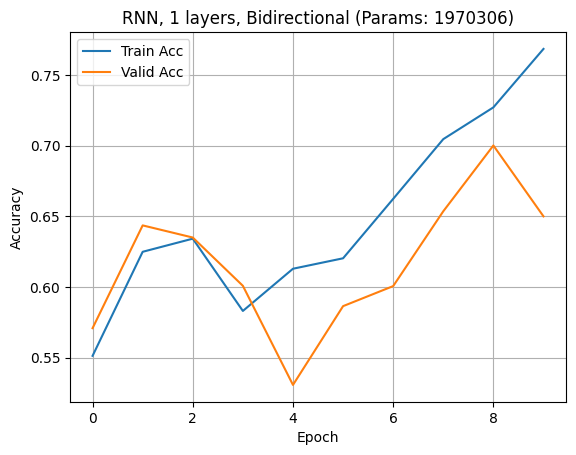

Test Accuracy: 0.652
              precision    recall  f1-score   support

           0       0.66      0.63      0.64     12500
           1       0.65      0.67      0.66     12500

    accuracy                           0.65     25000
   macro avg       0.65      0.65      0.65     25000
weighted avg       0.65      0.65      0.65     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─RNN: 1-2                               [2048, 64]                [2048, 128]               41,472
├─Linear: 1-3                            [32, 128]                 [32, 2]                   258
Total params: 1,995,138
Trainable params: 1,995,138
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 10.93
Input size (MB): 0.03
Forward/backward

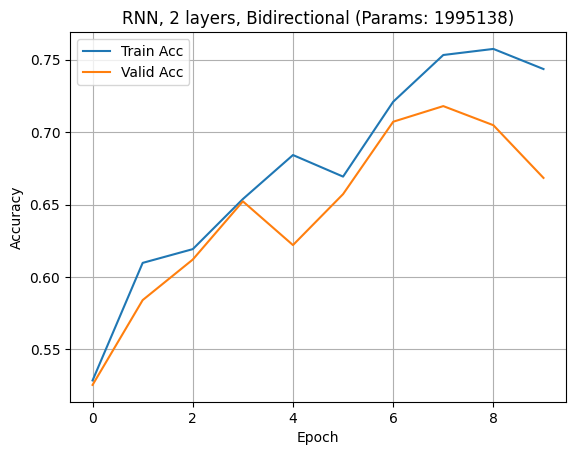

Test Accuracy: 0.653
              precision    recall  f1-score   support

           0       0.65      0.65      0.65     12500
           1       0.65      0.65      0.65     12500

    accuracy                           0.65     25000
   macro avg       0.65      0.65      0.65     25000
weighted avg       0.65      0.65      0.65     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─LSTM: 1-2                              [2048, 64]                [2048, 64]                33,280
├─Linear: 1-3                            [32, 64]                  [32, 2]                   130
Total params: 1,986,818
Trainable params: 1,986,818
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 4.42
Input size (MB): 0.03
Forward/backward 

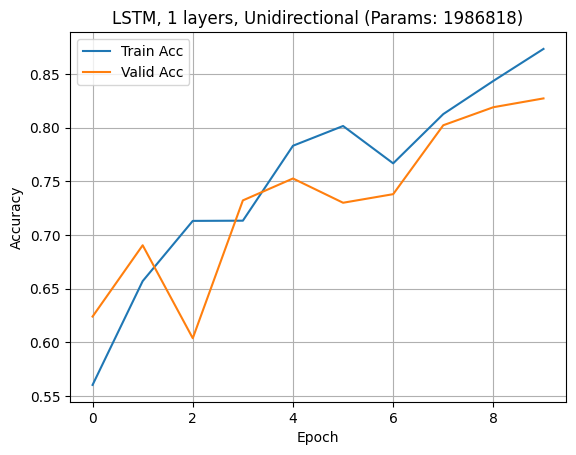

Test Accuracy: 0.821
              precision    recall  f1-score   support

           0       0.77      0.91      0.84     12500
           1       0.89      0.73      0.80     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─LSTM: 1-2                              [2048, 64]                [2048, 64]                66,560
├─Linear: 1-3                            [32, 64]                  [32, 2]                   130
Total params: 2,020,098
Trainable params: 2,020,098
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 8.79
Input size (MB): 0.03
Forward/backward 

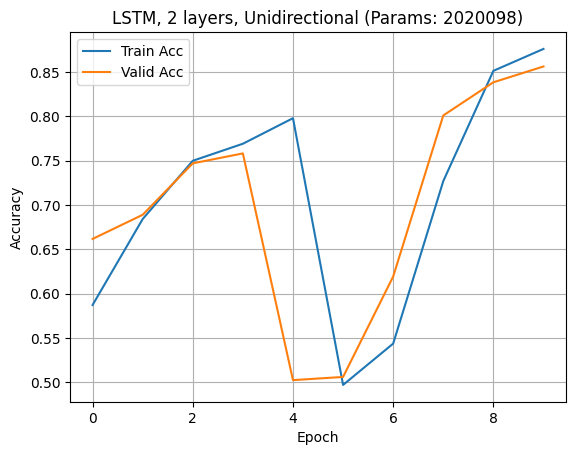

Test Accuracy: 0.846
              precision    recall  f1-score   support

           0       0.84      0.86      0.85     12500
           1       0.85      0.84      0.84     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─LSTM: 1-2                              [2048, 64]                [2048, 128]               66,560
├─Linear: 1-3                            [32, 128]                 [32, 2]                   258
Total params: 2,020,226
Trainable params: 2,020,226
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 17.51
Input size (MB): 0.03
Forward/backward

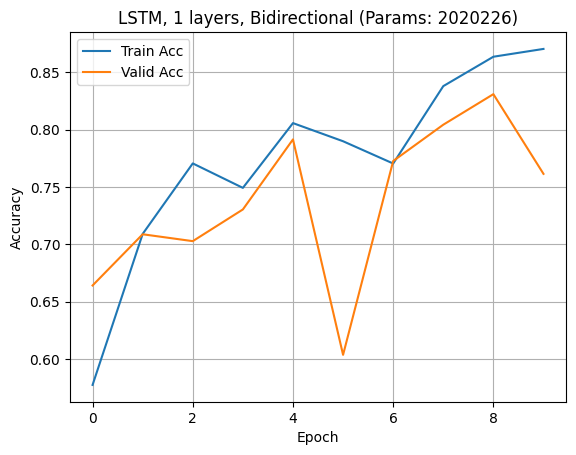

Test Accuracy: 0.750
              precision    recall  f1-score   support

           0       0.82      0.65      0.72     12500
           1       0.71      0.85      0.77     12500

    accuracy                           0.75     25000
   macro avg       0.76      0.75      0.75     25000
weighted avg       0.76      0.75      0.75     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─LSTM: 1-2                              [2048, 64]                [2048, 128]               165,888
├─Linear: 1-3                            [32, 128]                 [32, 2]                   258
Total params: 2,119,554
Trainable params: 2,119,554
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 43.55
Input size (MB): 0.03
Forward/backwar

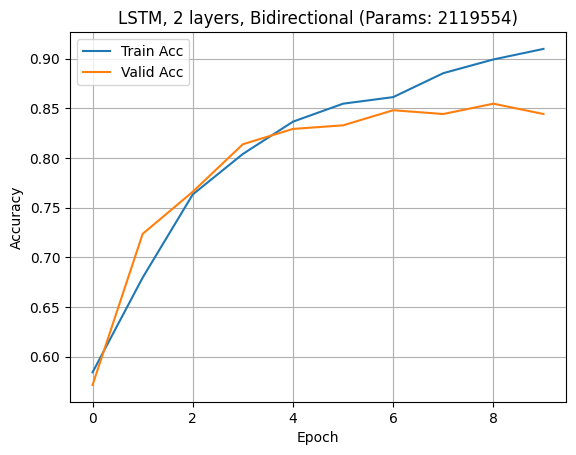

Test Accuracy: 0.830
              precision    recall  f1-score   support

           0       0.92      0.73      0.81     12500
           1       0.77      0.93      0.85     12500

    accuracy                           0.83     25000
   macro avg       0.85      0.83      0.83     25000
weighted avg       0.85      0.83      0.83     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─GRU: 1-2                               [2048, 64]                [2048, 64]                24,960
├─Linear: 1-3                            [32, 64]                  [32, 2]                   130
Total params: 1,978,498
Trainable params: 1,978,498
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 3.33
Input size (MB): 0.03
Forward/backward 

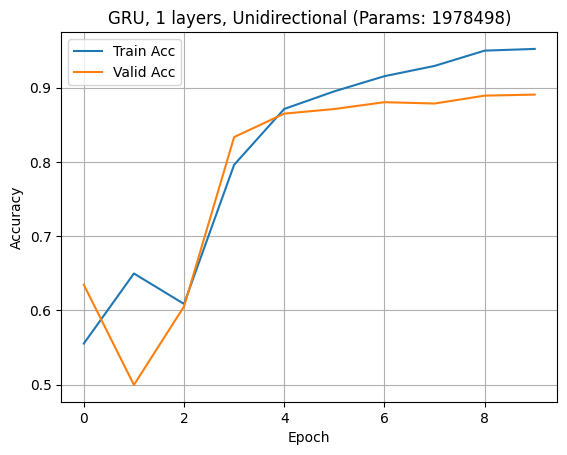

Test Accuracy: 0.872
              precision    recall  f1-score   support

           0       0.89      0.85      0.87     12500
           1       0.86      0.89      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─GRU: 1-2                               [2048, 64]                [2048, 64]                49,920
├─Linear: 1-3                            [32, 64]                  [32, 2]                   130
Total params: 2,003,458
Trainable params: 2,003,458
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 6.61
Input size (MB): 0.03
Forward/backward 

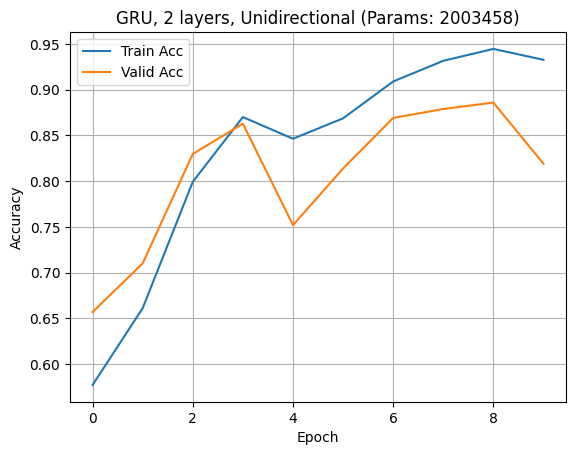

Test Accuracy: 0.807
              precision    recall  f1-score   support

           0       0.77      0.89      0.82     12500
           1       0.86      0.73      0.79     12500

    accuracy                           0.81     25000
   macro avg       0.82      0.81      0.81     25000
weighted avg       0.82      0.81      0.81     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─GRU: 1-2                               [2048, 64]                [2048, 128]               49,920
├─Linear: 1-3                            [32, 128]                 [32, 2]                   258
Total params: 2,003,586
Trainable params: 2,003,586
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 13.15
Input size (MB): 0.03
Forward/backward

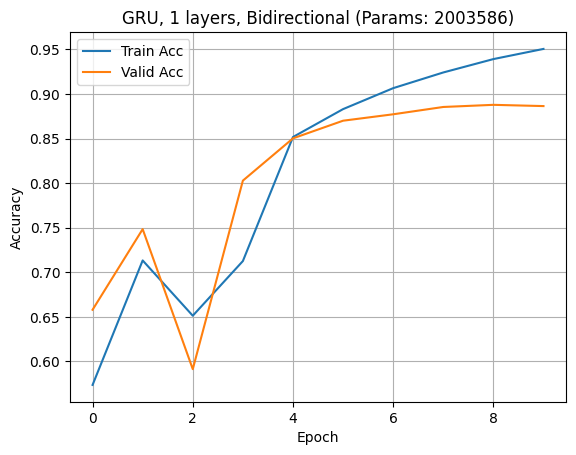

Test Accuracy: 0.865
              precision    recall  f1-score   support

           0       0.86      0.87      0.87     12500
           1       0.87      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.87      0.86      0.86     25000
weighted avg       0.87      0.86      0.86     25000

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 2]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─GRU: 1-2                               [2048, 64]                [2048, 128]               124,416
├─Linear: 1-3                            [32, 128]                 [32, 2]                   258
Total params: 2,078,082
Trainable params: 2,078,082
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 32.68
Input size (MB): 0.03
Forward/backwar

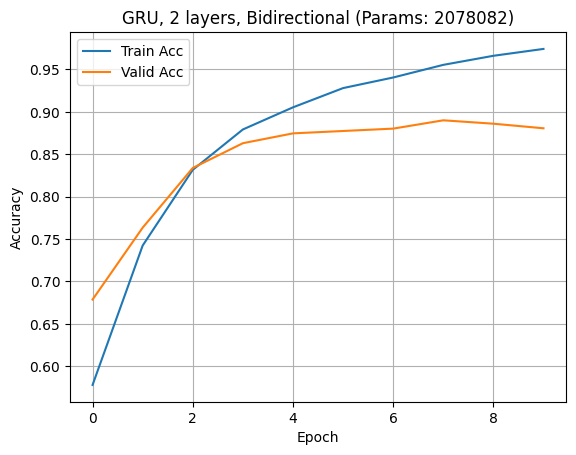

Test Accuracy: 0.868
              precision    recall  f1-score   support

           0       0.92      0.81      0.86     12500
           1       0.83      0.92      0.88     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



In [14]:
# (1) Data Loading
# Tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
vocab_size = tokenizer.vocab_size
print(f"Vocabulary size: {vocab_size}")

# Dataset
from torch.utils.data import RandomSampler
# IMDb Dataset
from datasets import load_dataset
dataset = load_dataset("imdb")
num_classes = len(dataset["train"].features["label"].names)
print(f"Number of classes: {num_classes}")
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=False)
tokenized = dataset.map(tokenize, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_trainval = tokenized["train"].train_test_split(test_size=0.2, seed=42)
train_set = tokenized_trainval["train"]
val_set = tokenized_trainval["test"]
test_set = tokenized["test"]
subset_size = len(train_set) // 2   # 1/2 of the training set is used
train_sampler = RandomSampler(train_set, num_samples=subset_size)

# MultiNLI Dataset
# from datasets import load_dataset
# dataset = load_dataset("multi_nli")
# num_classes = len(dataset["train"].features["label"].names)
# print(f"Number of classes: {num_classes}")
# def tokenize(batch):
#     return tokenizer(batch["premise"], batch["hypothesis"], truncation=True, padding=False)
# tokenized = dataset.map(tokenize, batched=True)
# tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
# train_set = tokenized["train"]
# val_set = tokenized["validation_matched"]
# test_set = tokenized["validation_mismatched"]
# subset_size = len(train_set) // 30   # 1/30 of the training set is used
# train_sampler = RandomSampler(train_set, num_samples=subset_size)

# Print the first example
print("First example from the dataset:")
print("Sentence:", tokenizer.decode(train_set[0]["input_ids"]))
print("Label:", dataset["train"].features["label"].names[train_set[0]["label"]])

# (2) DataLoader with padding
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

def collate_fn(batch):
    input_ids = pad_sequence([x["input_ids"] for x in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    attn_mask = pad_sequence([x["attention_mask"] for x in batch], batch_first=True, padding_value=0)
    labels = torch.tensor([x["label"] for x in batch])
    return input_ids, attn_mask, labels

train_loader = DataLoader(train_set, batch_size=32, sampler=train_sampler, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, collate_fn=collate_fn)

# (3) Model Definition
import torch.nn as nn

# RNN Classifier
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, RNN_class, num_layers, bidirectional):
        super().__init__()
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.rnn = RNN_class(embed_dim, hidden_dim, num_layers=num_layers, bidirectional=bidirectional, batch_first=True)
        self.fc_input_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(self.fc_input_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)  # (B, L) -> (B, L, embed_dim)
        lengths = attention_mask.sum(dim=1).cpu()  # Get lengths from attention mask
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)  # (B, L, embed_dim) -> (num_layers * num_directions, B, hidden_dim)
        if isinstance(hidden, tuple):  # LSTM
            hidden = hidden[0]  # Get the last hidden state
        if bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # Concatenate last states of both directions
        else:
            hidden = hidden[-1]  # Get the last hidden state for unidirectional RNN
        return self.fc(hidden)  # (B, hidden_dim * num_directions) -> (B, num_classes)


# (4) Training function
import torch.optim as optim

def train(train_loader, val_loader, model, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, mask, y in train_loader:
            x, mask, y = x.to(device), mask.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x, mask)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, mask, y in val_loader:
                x, mask, y = x.to(device), mask.to(device), y.to(device)
                out = model(x, mask)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state

# (5) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
import torchinfo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for RNN_class in [nn.RNN, nn.LSTM, nn.GRU]:
    for bidirectional in [False, True]:
        for num_layers in [1, 2]:
            embed_dim = 64
            hidden_dim = 64
            model = RNNClassifier(vocab_size, embed_dim, hidden_dim, num_classes,
                                  RNN_class=RNN_class, num_layers=num_layers, bidirectional=bidirectional
                                  ).to(device)

            print(torchinfo.summary(
                model,
                input_data=(torch.randint(0, vocab_size, (32, 64), device=device), 
                            torch.ones(32, 64, dtype=torch.int64, device=device)),
                col_names=["input_size", "output_size", "num_params"]
            ))

            train_accs, test_accs, best_state = train(train_loader, val_loader, model, device)
            num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            plt.plot(train_accs, label='Train Acc')
            plt.plot(test_accs, label='Valid Acc')
            plt.xlabel("Epoch")
            plt.ylabel("Accuracy")
            plt.title(f"{RNN_class.__name__}, {num_layers} layers, {'Bidirectional' if bidirectional else 'Unidirectional'} (Params: {num_params})")
            plt.legend()
            plt.grid(True)
            plt.show()

            # (6) Evaluate on test set
            model.load_state_dict(best_state)
            model.eval()
            all_preds, all_labels = [], []
            with torch.no_grad():
                for x, mask, y in test_loader:
                    x, mask, y = x.to(device), mask.to(device), y.to(device)
                    out = model(x, mask)
                    all_preds.append(out.argmax(1).cpu())
                    all_labels.append(y.cpu())
            all_preds = torch.cat(all_preds)
            all_labels = torch.cat(all_labels)
            print(f"Test Accuracy: {torch.sum(all_preds == all_labels).item() / len(all_labels):.3f}")

            from sklearn.metrics import classification_report
            print(classification_report(all_labels.numpy(), all_preds.numpy()))

# Exercise: Comparison (MultiNLI)

Vocabulary size: 30522
Number of classes: 3
First example from the dataset:
[CLS] conceptually cream skimming has two basic dimensions - product and geography. [SEP] product and geography are what make cream skimming work. [SEP]
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─RNN: 1-2                               [2048, 64]                [2048, 64]                8,320
├─Linear: 1-3                            [32, 64]                  [32, 3]                   195
Total params: 1,961,923
Trainable params: 1,961,923
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 1.15
Input size (MB): 0.03
Forward/backward pass size (MB): 2.10
Params size (MB): 7.85
Estimated Total Size (MB): 9.98
Epoch 1: Train Acc = 0.338, Val Acc = 0.332


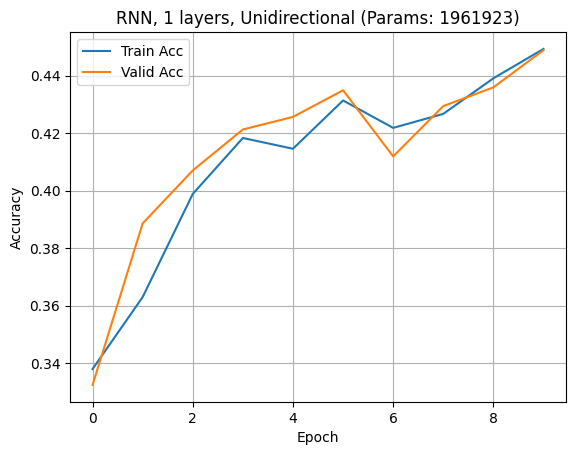

Test Accuracy: 0.457
              precision    recall  f1-score   support

           0       0.40      0.45      0.43      3463
           1       0.39      0.48      0.43      3129
           2       0.66      0.44      0.53      3240

    accuracy                           0.46      9832
   macro avg       0.49      0.46      0.46      9832
weighted avg       0.49      0.46      0.46      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─RNN: 1-2                               [2048, 64]                [2048, 64]                16,640
├─Linear: 1-3                            [32, 64]                  [32, 3]                   195
Total params: 1,970,243
Trainable params: 1,970,243
Non-trainable params: 0
Total mult-adds (Units.GI

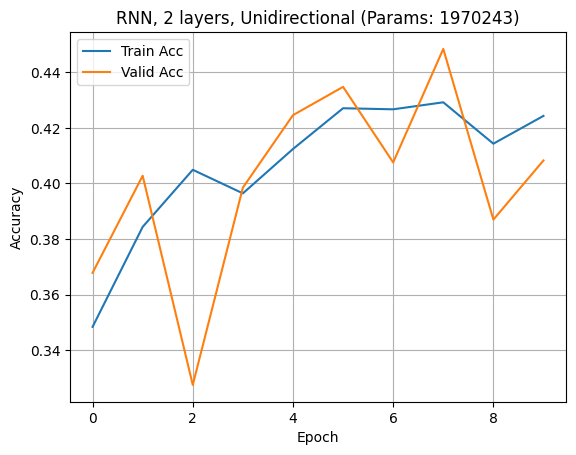

Test Accuracy: 0.422
              precision    recall  f1-score   support

           0       0.42      0.06      0.11      3463
           1       0.36      0.82      0.50      3129
           2       0.63      0.42      0.51      3240

    accuracy                           0.42      9832
   macro avg       0.47      0.43      0.37      9832
weighted avg       0.47      0.42      0.36      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─RNN: 1-2                               [2048, 64]                [2048, 128]               16,640
├─Linear: 1-3                            [32, 128]                 [32, 3]                   387
Total params: 1,970,435
Trainable params: 1,970,435
Non-trainable params: 0
Total mult-adds (Units.GI

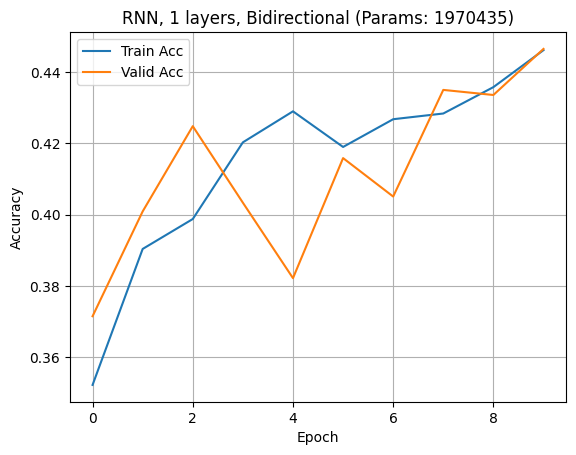

Test Accuracy: 0.455
              precision    recall  f1-score   support

           0       0.41      0.55      0.47      3463
           1       0.37      0.34      0.36      3129
           2       0.63      0.47      0.54      3240

    accuracy                           0.46      9832
   macro avg       0.47      0.45      0.46      9832
weighted avg       0.47      0.46      0.46      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─RNN: 1-2                               [2048, 64]                [2048, 128]               41,472
├─Linear: 1-3                            [32, 128]                 [32, 3]                   387
Total params: 1,995,267
Trainable params: 1,995,267
Non-trainable params: 0
Total mult-adds (Units.GI

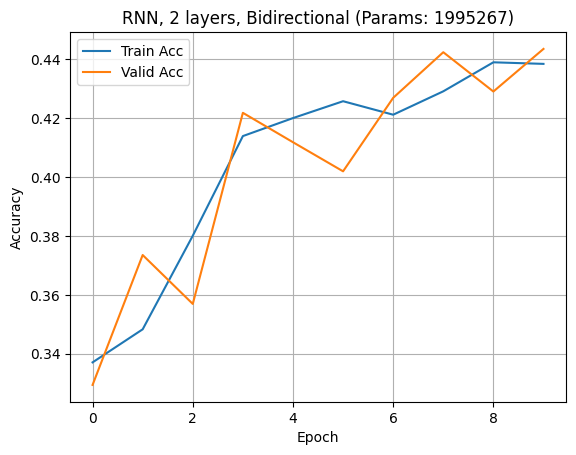

Test Accuracy: 0.461
              precision    recall  f1-score   support

           0       0.42      0.70      0.53      3463
           1       0.38      0.10      0.16      3129
           2       0.56      0.55      0.55      3240

    accuracy                           0.46      9832
   macro avg       0.45      0.45      0.41      9832
weighted avg       0.45      0.46      0.42      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─LSTM: 1-2                              [2048, 64]                [2048, 64]                33,280
├─Linear: 1-3                            [32, 64]                  [32, 3]                   195
Total params: 1,986,883
Trainable params: 1,986,883
Non-trainable params: 0
Total mult-adds (Units.GI

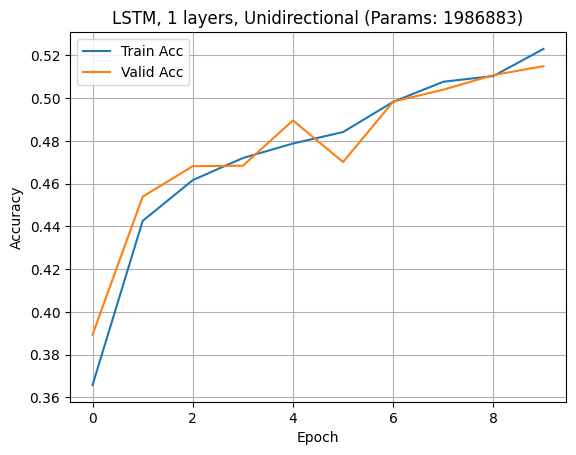

Test Accuracy: 0.514
              precision    recall  f1-score   support

           0       0.49      0.50      0.49      3463
           1       0.44      0.50      0.47      3129
           2       0.64      0.54      0.59      3240

    accuracy                           0.51      9832
   macro avg       0.52      0.51      0.52      9832
weighted avg       0.52      0.51      0.52      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─LSTM: 1-2                              [2048, 64]                [2048, 64]                66,560
├─Linear: 1-3                            [32, 64]                  [32, 3]                   195
Total params: 2,020,163
Trainable params: 2,020,163
Non-trainable params: 0
Total mult-adds (Units.GI

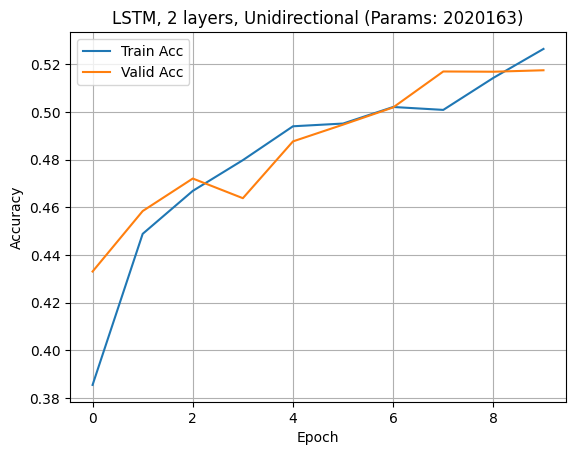

Test Accuracy: 0.517
              precision    recall  f1-score   support

           0       0.49      0.50      0.50      3463
           1       0.44      0.58      0.50      3129
           2       0.71      0.48      0.57      3240

    accuracy                           0.52      9832
   macro avg       0.55      0.52      0.52      9832
weighted avg       0.55      0.52      0.52      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─LSTM: 1-2                              [2048, 64]                [2048, 128]               66,560
├─Linear: 1-3                            [32, 128]                 [32, 3]                   387
Total params: 2,020,355
Trainable params: 2,020,355
Non-trainable params: 0
Total mult-adds (Units.GI

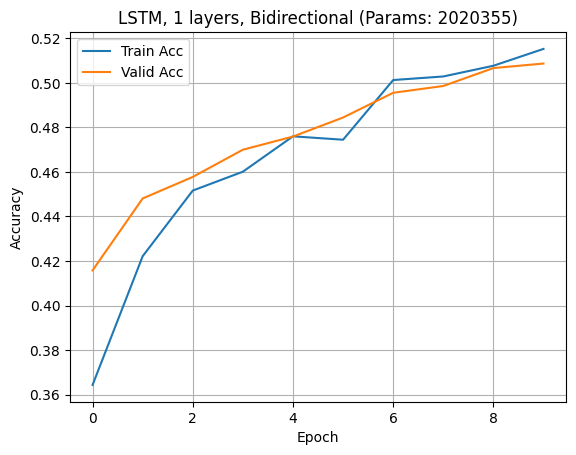

Test Accuracy: 0.502
              precision    recall  f1-score   support

           0       0.49      0.48      0.48      3463
           1       0.41      0.52      0.46      3129
           2       0.66      0.51      0.57      3240

    accuracy                           0.50      9832
   macro avg       0.52      0.50      0.51      9832
weighted avg       0.52      0.50      0.51      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─LSTM: 1-2                              [2048, 64]                [2048, 128]               165,888
├─Linear: 1-3                            [32, 128]                 [32, 3]                   387
Total params: 2,119,683
Trainable params: 2,119,683
Non-trainable params: 0
Total mult-adds (Units.G

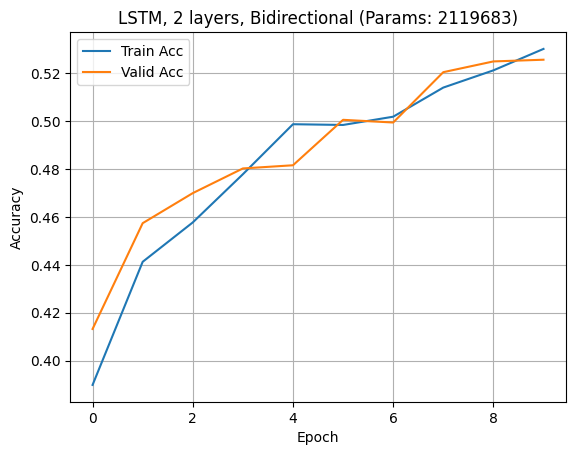

Test Accuracy: 0.534
              precision    recall  f1-score   support

           0       0.51      0.56      0.53      3463
           1       0.47      0.46      0.46      3129
           2       0.63      0.58      0.60      3240

    accuracy                           0.53      9832
   macro avg       0.54      0.53      0.53      9832
weighted avg       0.54      0.53      0.53      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─GRU: 1-2                               [2048, 64]                [2048, 64]                24,960
├─Linear: 1-3                            [32, 64]                  [32, 3]                   195
Total params: 1,978,563
Trainable params: 1,978,563
Non-trainable params: 0
Total mult-adds (Units.GI

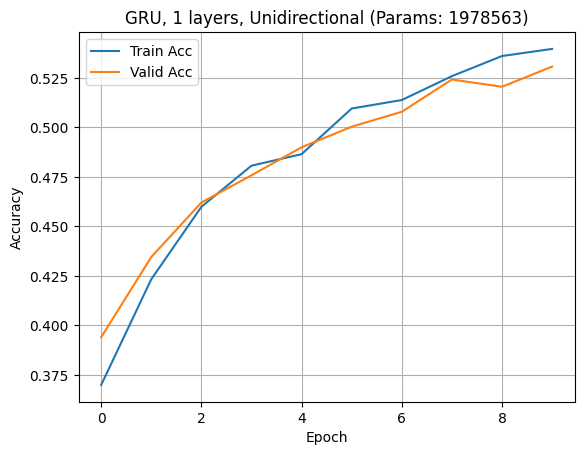

Test Accuracy: 0.532
              precision    recall  f1-score   support

           0       0.50      0.53      0.51      3463
           1       0.46      0.57      0.50      3129
           2       0.71      0.50      0.59      3240

    accuracy                           0.53      9832
   macro avg       0.56      0.53      0.54      9832
weighted avg       0.56      0.53      0.54      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─GRU: 1-2                               [2048, 64]                [2048, 64]                49,920
├─Linear: 1-3                            [32, 64]                  [32, 3]                   195
Total params: 2,003,523
Trainable params: 2,003,523
Non-trainable params: 0
Total mult-adds (Units.GI

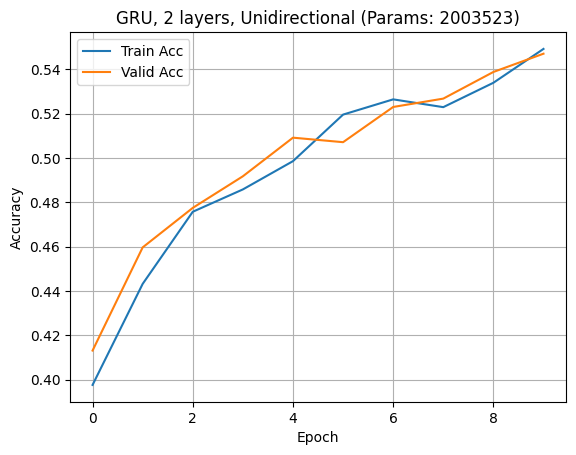

Test Accuracy: 0.550
              precision    recall  f1-score   support

           0       0.50      0.66      0.57      3463
           1       0.51      0.40      0.45      3129
           2       0.66      0.57      0.61      3240

    accuracy                           0.55      9832
   macro avg       0.56      0.55      0.54      9832
weighted avg       0.56      0.55      0.55      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─GRU: 1-2                               [2048, 64]                [2048, 128]               49,920
├─Linear: 1-3                            [32, 128]                 [32, 3]                   387
Total params: 2,003,715
Trainable params: 2,003,715
Non-trainable params: 0
Total mult-adds (Units.GI

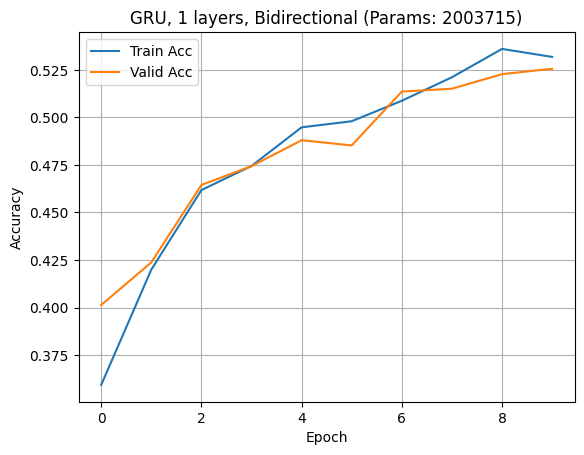

Test Accuracy: 0.522
              precision    recall  f1-score   support

           0       0.51      0.53      0.52      3463
           1       0.47      0.40      0.43      3129
           2       0.57      0.63      0.60      3240

    accuracy                           0.52      9832
   macro avg       0.52      0.52      0.52      9832
weighted avg       0.52      0.52      0.52      9832

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
RNNClassifier                            [32, 64]                  [32, 3]                   --
├─Embedding: 1-1                         [32, 64]                  [32, 64, 64]              1,953,408
├─GRU: 1-2                               [2048, 64]                [2048, 128]               124,416
├─Linear: 1-3                            [32, 128]                 [32, 3]                   387
Total params: 2,078,211
Trainable params: 2,078,211
Non-trainable params: 0
Total mult-adds (Units.G

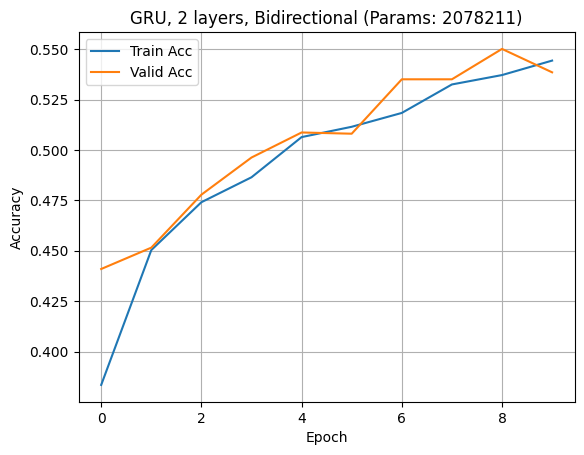

Test Accuracy: 0.530
              precision    recall  f1-score   support

           0       0.52      0.49      0.51      3463
           1       0.44      0.60      0.51      3129
           2       0.73      0.50      0.59      3240

    accuracy                           0.53      9832
   macro avg       0.56      0.53      0.53      9832
weighted avg       0.56      0.53      0.53      9832



In [ ]:
# (1) Data Loading
# Tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
vocab_size = tokenizer.vocab_size
print(f"Vocabulary size: {vocab_size}")

# Dataset
from torch.utils.data import RandomSampler
# IMDb Dataset
# from datasets import load_dataset
# dataset = load_dataset("imdb")
# num_classes = len(dataset["train"].features["label"].names)
# print(f"Number of classes: {num_classes}")
# def tokenize(batch):
#     return tokenizer(batch["text"], truncation=True, padding=False)
# tokenized = dataset.map(tokenize, batched=True)
# tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
# tokenized_trainval = tokenized["train"].train_test_split(test_size=0.2, seed=42)
# train_set = tokenized_trainval["train"]
# val_set = tokenized_trainval["test"]
# test_set = tokenized["test"]
# subset_size = len(train_set) // 2   # 1/2 of the training set is used
# train_sampler = RandomSampler(train_set, num_samples=subset_size)

# MultiNLI Dataset
from datasets import load_dataset
dataset = load_dataset("multi_nli")
num_classes = len(dataset["train"].features["label"].names)
print(f"Number of classes: {num_classes}")
def tokenize(batch):
    return tokenizer(batch["premise"], batch["hypothesis"], truncation=True, padding=False)
tokenized = dataset.map(tokenize, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
train_set = tokenized["train"]
val_set = tokenized["validation_matched"]
test_set = tokenized["validation_mismatched"]
subset_size = len(train_set) // 30   # 1/30 of the training set is used
train_sampler = RandomSampler(train_set, num_samples=subset_size)

# Print the first example
print("First example from the dataset:")
print("Sentence:", tokenizer.decode(train_set[0]["input_ids"]))
print("Label:", dataset["train"].features["label"].names[train_set[0]["label"]])

# (2) DataLoader with padding
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

def collate_fn(batch):
    input_ids = pad_sequence([x["input_ids"] for x in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    attn_mask = pad_sequence([x["attention_mask"] for x in batch], batch_first=True, padding_value=0)
    labels = torch.tensor([x["label"] for x in batch])
    return input_ids, attn_mask, labels

train_loader = DataLoader(train_set, batch_size=32, sampler=train_sampler, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, collate_fn=collate_fn)

# (3) Model Definition
import torch.nn as nn

# RNN Classifier
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, RNN_class, num_layers, bidirectional):
        super().__init__()
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.rnn = RNN_class(embed_dim, hidden_dim, num_layers=num_layers, bidirectional=bidirectional, batch_first=True)
        self.fc_input_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(self.fc_input_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        emb = self.embedding(input_ids)  # (B, L) -> (B, L, embed_dim)
        lengths = attention_mask.sum(dim=1).cpu()  # Get lengths from attention mask
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)  # (B, L, embed_dim) -> (num_layers * num_directions, B, hidden_dim)
        if isinstance(hidden, tuple):  # LSTM
            hidden = hidden[0]  # Get the last hidden state
        if bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # Concatenate last states of both directions
        else:
            hidden = hidden[-1]  # Get the last hidden state for unidirectional RNN
        return self.fc(hidden)  # (B, hidden_dim * num_directions) -> (B, num_classes)


# (4) Training function
import torch.optim as optim

def train(train_loader, val_loader, model, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, mask, y in train_loader:
            x, mask, y = x.to(device), mask.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x, mask)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, mask, y in val_loader:
                x, mask, y = x.to(device), mask.to(device), y.to(device)
                out = model(x, mask)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state

# (5) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
import torchinfo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for RNN_class in [nn.RNN, nn.LSTM, nn.GRU]:
    for bidirectional in [False, True]:
        for num_layers in [1, 2]:
            embed_dim = 64
            hidden_dim = 64
            model = RNNClassifier(vocab_size, embed_dim, hidden_dim, num_classes,
                                  RNN_class=RNN_class, num_layers=num_layers, bidirectional=bidirectional
                                  ).to(device)

            print(torchinfo.summary(
                model,
                input_data=(torch.randint(0, vocab_size, (32, 64), device=device), 
                            torch.ones(32, 64, dtype=torch.int64, device=device)),
                col_names=["input_size", "output_size", "num_params"]
            ))

            train_accs, test_accs, best_state = train(train_loader, val_loader, model, device)
            num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            plt.plot(train_accs, label='Train Acc')
            plt.plot(test_accs, label='Valid Acc')
            plt.xlabel("Epoch")
            plt.ylabel("Accuracy")
            plt.title(f"{RNN_class.__name__}, {num_layers} layers, {'Bidirectional' if bidirectional else 'Unidirectional'} (Params: {num_params})")
            plt.legend()
            plt.grid(True)
            plt.show()

            # (6) Evaluate on test set
            model.load_state_dict(best_state)
            model.eval()
            all_preds, all_labels = [], []
            with torch.no_grad():
                for x, mask, y in test_loader:
                    x, mask, y = x.to(device), mask.to(device), y.to(device)
                    out = model(x, mask)
                    all_preds.append(out.argmax(1).cpu())
                    all_labels.append(y.cpu())
            all_preds = torch.cat(all_preds)
            all_labels = torch.cat(all_labels)
            print(f"Test Accuracy: {torch.sum(all_preds == all_labels).item() / len(all_labels):.3f}")

            from sklearn.metrics import classification_report
            print(classification_report(all_labels.numpy(), all_preds.numpy()))